# Explicación de predicciones para una Red Neuronal usando Random Forest
- Integrantes: Felipe Peralta, Samantha Suquilanda

## Objetivo
Predecir **intención de compra en e-commerce** usando **Random Forest** y combinar dos técnicas de XAI: **Feature Importance (global)** y **LIME (local)** para obtener explicaciones a nivel de modelo y de instancia individual.

## Modelo Utilizado
- **Algoritmo**: Random Forest (100 árboles de decisión)
- **Hiperparámetros**: 
  - n_estimators=100
  - class_weight='balanced' (manejo de desbalanceo)
  - max_features='sqrt'
  - random_state=42
- **Dataset**: Online Shoppers Purchasing Intention (12,330 sesiones, 18 características)
- **Ventaja del RF**: Interpretable nativamente mediante importancia de variables



## Técnicas de Explicabilidad (XAI)

### 1. Feature Importance (Nativa de Random Forest)
**Método**: Mean Decrease in Impurity (MDI)
- **Alcance**: Global (todo el dataset)
- **Cálculo**: Suma de reducción de Gini/Entropía en cada división
- **Pregunta**: "¿Qué variables son más importantes PARA EL MODELO?"

### 2. LIME (Local Interpretable Model-agnostic Explanations)
**Método**: Perturbaciones locales
- **Alcance**: Local (por cliente)
- **Cálculo**: Perturbar características y ajustar modelo lineal local
- **Pregunta**: "¿Por qué ESTE CLIENTE específico fue clasificado así?"


## Comparación: Feature Importance vs LIME

| Aspecto | Feature Importance | LIME |
|---------|-------------------|------|
| **Nivel** | Global (modelo completo) | Local (una instancia) |
| **Velocidad** | Instantánea (ya calculada) | Lenta (~10-30 seg/instancia) |
| **Interpretación** | "Variable X es importante en general" | "Para ESTE cliente, X contribuyó Y%" |
| **Ejemplo** | "PageValues es 35% importante" | "PageValues=85 aportó +38% a la predicción" |
| **Uso** | Análisis exploratorio, selección de features | Debugging de casos específicos, auditoría |



## Carga de Librerías y Datos

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import lime
import lime.lime_tabular
from sklearn.tree import plot_tree
import os

# MLflow
import mlflow
import mlflow.sklearn

In [3]:
df = pd.read_csv('../data/online+shoppers+purchasing+intention+dataset/online_shoppers_intention.csv')

## Configuración de rutas de salida

In [4]:
# Crear estructura de carpetas para este modelo
output_dir = '../exportaciones/rf-shoppers-lime'
mlflow_dir = os.path.join(output_dir, 'mlruns')
models_dir = os.path.join(output_dir, 'models')
plots_dir = os.path.join(output_dir, 'plots')
explanations_dir = os.path.join(output_dir, 'explanations')
trees_dir = os.path.join(output_dir, 'trees')

# Crear directorios si no existen
os.makedirs(output_dir, exist_ok=True)
os.makedirs(mlflow_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(explanations_dir, exist_ok=True)
os.makedirs(trees_dir, exist_ok=True)

print(f"Estructura de carpetas creada:")
print(f"  - Directorio base: {output_dir}")
print(f"  - MLflow tracking: {mlflow_dir}")
print(f"  - Modelos: {models_dir}")
print(f"  - Gráficas: {plots_dir}")
print(f"  - Explicaciones LIME: {explanations_dir}")
print(f"  - Árboles individuales: {trees_dir}")

Estructura de carpetas creada:
  - Directorio base: ../exportaciones/rf-shoppers-lime
  - MLflow tracking: ../exportaciones/rf-shoppers-lime/mlruns
  - Modelos: ../exportaciones/rf-shoppers-lime/models
  - Gráficas: ../exportaciones/rf-shoppers-lime/plots
  - Explicaciones LIME: ../exportaciones/rf-shoppers-lime/explanations
  - Árboles individuales: ../exportaciones/rf-shoppers-lime/trees


## Análisis Exploratorio de Datos

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
print(f"Dimensiones del dataset: {df.shape}")
print("Tipos de datos y nulos:")
print(df.info())

Dimensiones del dataset: (12330, 18)
Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region         

In [7]:
print("Estadísticas:")
display(df.describe())

Estadísticas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [9]:
# mirar nulos y duplicados
nulos = df.isnull().sum().sum()
duplicados = df.duplicated().sum()
print(f"Total de valores nulos: {nulos}")
print(f"Filas duplicadas: {duplicados}")

Total de valores nulos: 0
Filas duplicadas: 125


In [10]:
# borrar duplicados
df.drop_duplicates(inplace=True)

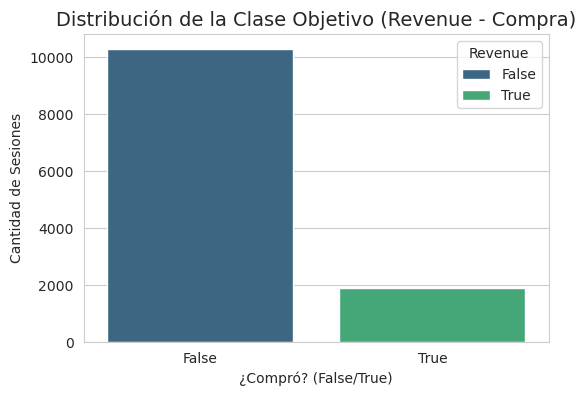

Compras: 15.63%
No Compras: 84.37%


In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Revenue', data=df, palette='viridis', hue='Revenue')
plt.title('Distribución de la Clase Objetivo (Revenue - Compra)', fontsize=14)
plt.xlabel('¿Compró? (False/True)')
plt.ylabel('Cantidad de Sesiones')
plt.show()

compra_ratio = df['Revenue'].value_counts(normalize=True)
print(f"Compras: {compra_ratio.iloc[1]*100:.2f}%")
print(f"No Compras: {compra_ratio.iloc[0]*100:.2f}%")

- El dataset está desbalanceado

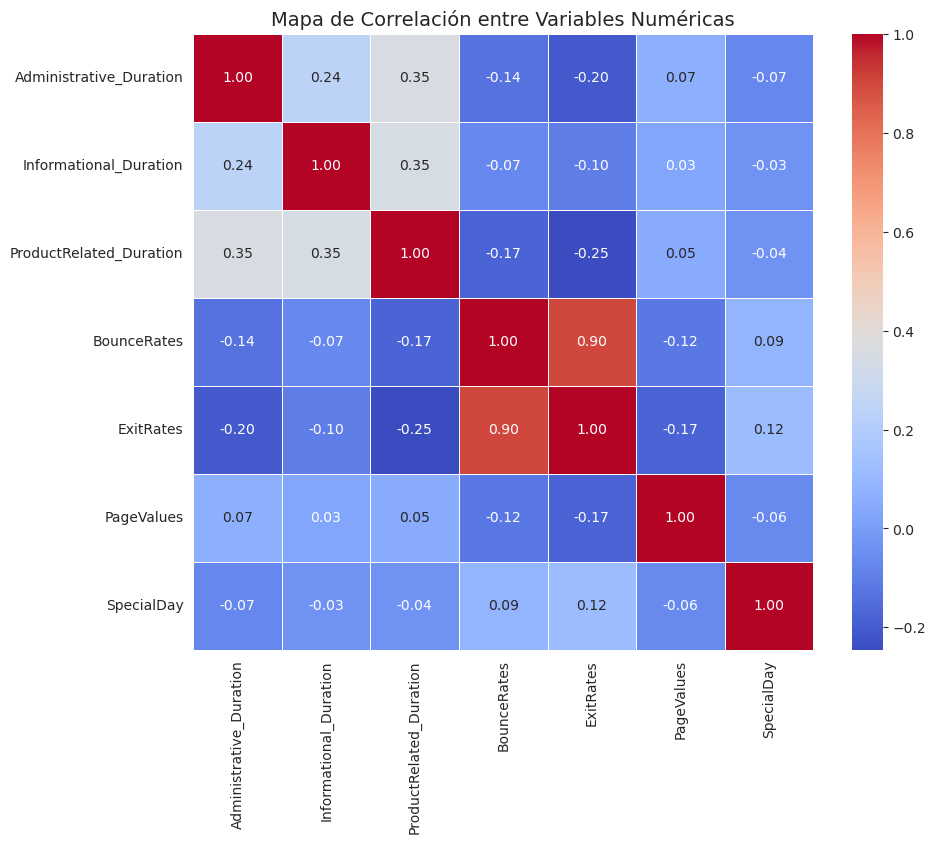

In [12]:
# Seleccionamos solo las columnas numéricas principales para el mapa de calor
cols_numericas = ['Administrative_Duration', 'Informational_Duration', 
                  'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
                  'PageValues', 'SpecialDay']

plt.figure(figsize=(10, 8))
# Calculamos la correlación
corr_matrix = df[cols_numericas].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.show()

- Alta correlación entre 'BounceRates' y 'ExitRates'

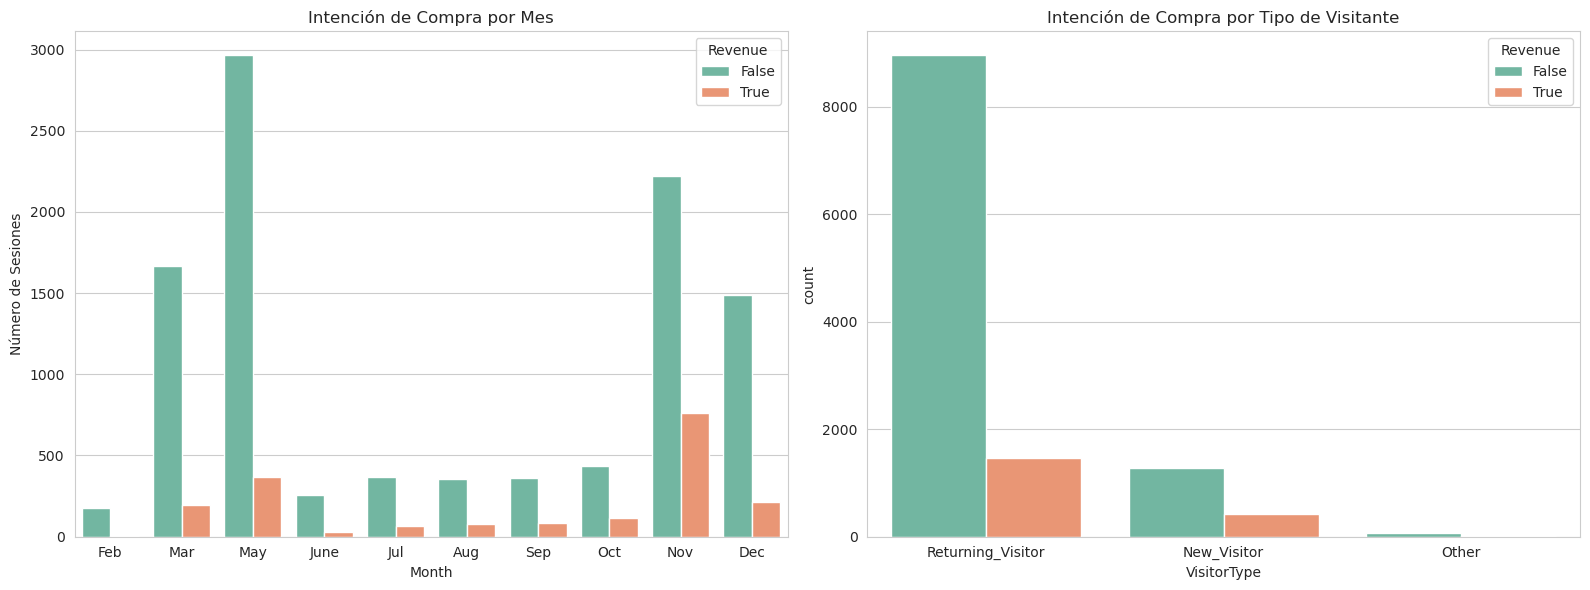

In [13]:
# analisis categorico con la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas por Mes
sns.countplot(x='Month', hue='Revenue', data=df, 
              order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
              palette='Set2', ax=axes[0])
axes[0].set_title('Intención de Compra por Mes')
axes[0].set_ylabel('Número de Sesiones')

# Ventas por Tipo de Visitante
sns.countplot(x='VisitorType', hue='Revenue', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Intención de Compra por Tipo de Visitante')

plt.tight_layout()
plt.show()

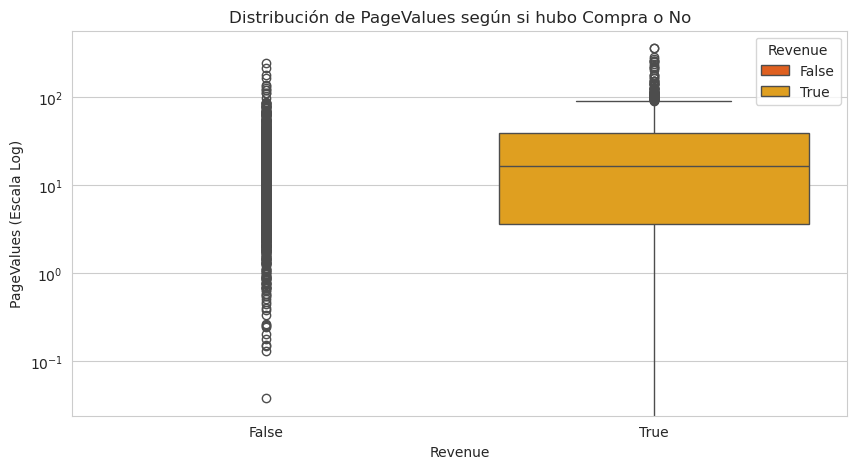

In [14]:
# detectar outliers en PageValues
plt.figure(figsize=(10, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df, palette='autumn', hue='Revenue')
plt.title('Distribución de PageValues según si hubo Compra o No')
plt.yscale('log') # Escala logarítmica para ver mejor porque hay muchos ceros
plt.ylabel('PageValues (Escala Log)')
plt.show()

## Creación y Entrenamiento del Modelo con Random Forest

In [15]:
# pre procesamiento de datos

# Convertir booleanos a 0 y 1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# Encoding de variables categóricas (Month, VisitorType) usando One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

# Separar Features (X) y Target (y)
X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

# Convertir a flotantes
X = X.astype('float32')

# Dividir en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a tensores de TensorFlow
X_train_tensor = tf.convert_to_tensor(X_train_scaled, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

print(f"Forma de los datos de entrada: {X_train_tensor.shape}")

Forma de los datos de entrada: (9764, 26)


Reporte Random Forest
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.75      0.51      0.60       362

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.77      2441
weighted avg       0.89      0.90      0.89      2441



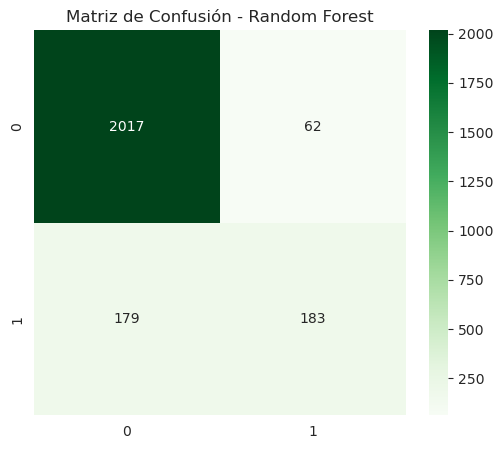

In [16]:
# 1. Configurar Random Forest con balanceo de clases
rf_model = RandomForestClassifier(n_estimators=100, 
                                  class_weight='balanced', 
                                  random_state=42,
                                  n_jobs=-1)

# 2. Entrenar
rf_model.fit(X_train, y_train)

# 3. Evaluar
y_pred_rf = rf_model.predict(X_test)

print("Reporte Random Forest")
print(classification_report(y_test, y_pred_rf))

# Matriz de Confusión
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

### Configuración de MLflow

In [19]:
# Configurar MLflow con tracking URI específico
mlflow.set_tracking_uri(f"file:///{os.path.abspath(mlflow_dir)}")
mlflow.set_experiment("RF-Shoppers-LIME")

# Definir parámetros del modelo
model_params = {
    "model_type": "RandomForest",
    "n_estimators": 100,
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "test_size": 0.2,
    "xai_method": "LIME",
    "lime_num_features": 10,
    "max_features": "sqrt",
    "bootstrap": True
}

print("MLflow configurado")
print(f"Experimento: RF-Shoppers-LIME")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Parámetros registrados: {len(model_params)} parámetros")

MLflow configurado
Experimento: RF-Shoppers-LIME
Tracking URI: file:////home/felipep/Documentos/universidad/universidad 7mo/aprendizaje automatico/practica 3/exportaciones/rf-shoppers-lime/mlruns
Parámetros registrados: 10 parámetros


### Entrenamiento y evaluación con MLflow

Iniciando entrenamiento con MLflow tracking...


2026/01/12 21:57:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Entrenamiento completado
Run ID: 19fe856afe1045ee96a50100f32a04ae

Reporte Random Forest
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2079
           1       0.75      0.51      0.60       362

    accuracy                           0.90      2441
   macro avg       0.83      0.74      0.77      2441
weighted avg       0.89      0.90      0.89      2441


Métricas:
  - Accuracy: 0.9013
  - Precision: 0.7469
  - Recall: 0.5055
  - F1-Score: 0.6030
  - AUC: 0.9244


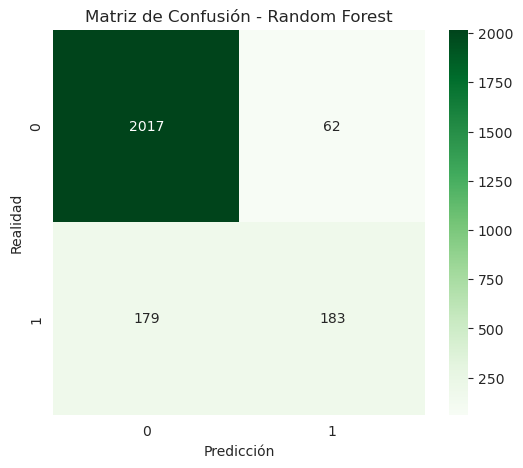

Matriz de confusión guardada: ../exportaciones/rf-shoppers-lime/plots/confusion_matrix.png


In [20]:
# Iniciar MLflow run para tracking
print("Iniciando entrenamiento con MLflow tracking...")

with mlflow.start_run(run_name="RF_Shoppers_LIME_v1") as run:
    
    # Loggear parámetros
    mlflow.log_params(model_params)
    
    # Loggear tags
    mlflow.set_tag("model_type", "Random Forest")
    mlflow.set_tag("framework", "scikit-learn")
    mlflow.set_tag("dataset", "Online Shoppers Intention")
    mlflow.set_tag("xai_method", "LIME")
    mlflow.set_tag("problem_type", "binary_classification")
    
    # Configurar y entrenar Random Forest
    rf_model = RandomForestClassifier(
        n_estimators=model_params["n_estimators"],
        class_weight=model_params["class_weight"],
        random_state=model_params["random_state"],
        n_jobs=model_params["n_jobs"]
    )
    
    rf_model.fit(X_train, y_train)
    
    # Evaluar
    y_pred_rf = rf_model.predict(X_test)
    y_pred_proba = rf_model.predict_proba(X_test)
    
    # Calcular métricas
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    
    test_accuracy = accuracy_score(y_test, y_pred_rf)
    test_precision = precision_score(y_test, y_pred_rf)
    test_recall = recall_score(y_test, y_pred_rf)
    test_f1 = f1_score(y_test, y_pred_rf)
    test_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    
    # Loggear métricas
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision", test_precision)
    mlflow.log_metric("test_recall", test_recall)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_auc", test_auc)
    
    # Loggear modelo
    mlflow.sklearn.log_model(rf_model, "model")
    
    print(f"\nEntrenamiento completado")
    print(f"Run ID: {run.info.run_id}")
    print("\nReporte Random Forest")
    print(classification_report(y_test, y_pred_rf))
    print(f"\nMétricas:")
    print(f"  - Accuracy: {test_accuracy:.4f}")
    print(f"  - Precision: {test_precision:.4f}")
    print(f"  - Recall: {test_recall:.4f}")
    print(f"  - F1-Score: {test_f1:.4f}")
    print(f"  - AUC: {test_auc:.4f}")
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title('Matriz de Confusión - Random Forest')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    
    # Guardar matriz de confusión
    cm_path = os.path.join(plots_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    # Loggear en MLflow
    mlflow.log_artifact(cm_path, "plots")
    print(f"Matriz de confusión guardada: {cm_path}")

## Explicación de Predicciones con Random Forest

## Función Más Importante #1: Feature Importance
```python
rf_model.feature_importances_
```
- **Propósito**: Obtener ranking global de variables más discriminantes
- **Cálculo automático**: Random Forest lo calcula durante entrenamiento
- **Interpretación**:
  ```
  PageValues: 0.35 (35%)
    → Variable que más reduce impureza en promedio
    → Mejor división en raíz de árboles
  
  ProductRelated_Duration: 0.24 (24%)
    → Segunda mejor variable
  
  ExitRates: 0.15 (15%)
    → Útil pero menos discriminante
  ```


### Importancia de características

Gráfica de importancia guardada: ../exportaciones/rf-shoppers-lime/plots/feature_importance.png


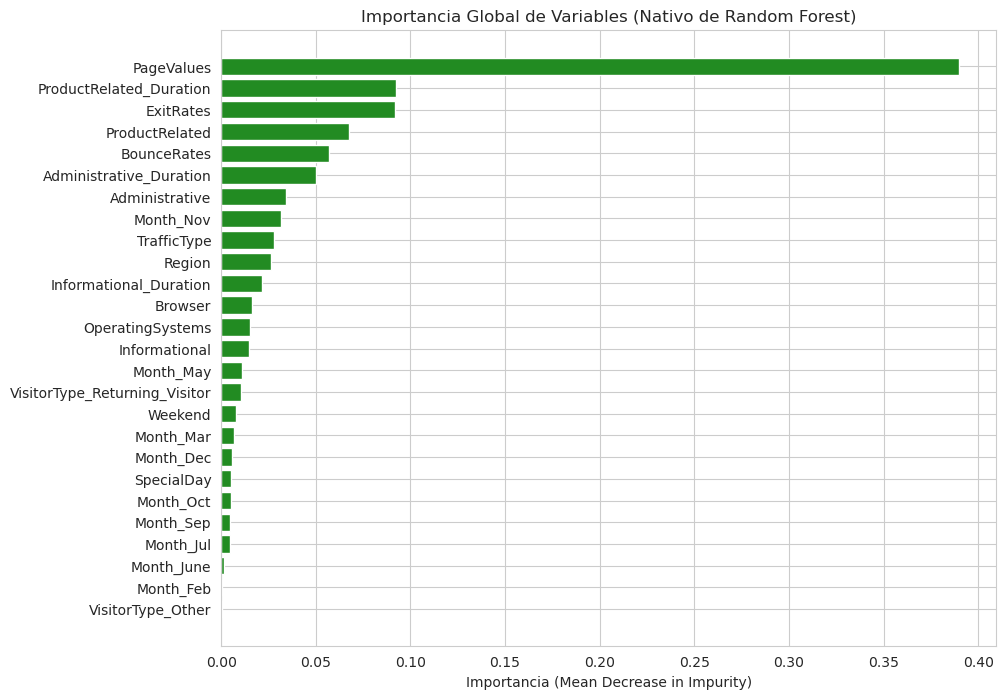

In [21]:
# Graficar importancia de características
def graficar_importancia_rf_guardado(model, feature_names, save_path=None):
    # Extraer la importancia calculada durante el entrenamiento
    importances = model.feature_importances_
    
    # Crear DataFrame para ordenar
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    
    # Ordenar descendente
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
    
    # Graficar
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='forestgreen')
    plt.xlabel("Importancia (Mean Decrease in Impurity)")
    plt.title("Importancia Global de Variables (Nativo de Random Forest)")
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Gráfica de importancia guardada: {save_path}")
        # Loggear en MLflow
        mlflow.log_artifact(save_path, "plots")
    
    plt.show()

# Ejecutar con guardado
importance_path = os.path.join(plots_dir, 'feature_importance.png')
graficar_importancia_rf_guardado(rf_model, X.columns, save_path=importance_path)

##  Patrones Clave Descubiertos

### Variables que IMPULSAN la Compra:
1. **PageValues** (35% importancia) 
   - Si el cliente visita páginas de productos con transacciones previas
   - Insight: Asegurar que productos populares aparezcan rápido

2. **ProductRelated_Duration** (24%)
   - Más de 8 minutos navegando productos = señal de compra
   - Insight: Mejorar descripciones para que pasen más tiempo

3. **Month = Noviembre** (4%)
   - Temporada alta de compras
   - Insight: Concentrar presupuesto de ads en Oct-Dic

### Variables que FRENAN la Compra:
1. **ExitRate > 0.6** 
   - Si el cliente sale de más del 60% de páginas visitadas
   - Insight: Hay páginas problemáticas que espantan usuarios

2. **BounceRate > 0.03**
   - Si rebota más del 3%, el tráfico es basura
   - Insight: Filtrar keywords o canales que traen rebotes

3. **PageValues = 0**
   - Si no interactúa con productos valiosos, no comprará
   - Insight: Mejorar recomendaciones y navegación

## Explicaciones LIME individuales

## Función Más Importante #2: LIME Explicador
```python
explicar_cliente_lime(idx, model, X_test, y_test)
```
- **Propósito**: Explicar UNA predicción individual
- **Entrada**: 
  - `idx`: Índice del cliente a explicar
  - `model`: Random Forest entrenado
  - `X_test`, `y_test`: Datos de prueba
- **Salida**: Visualización con variables que aumentan/reducen probabilidad
- **Funcionamiento**:
  1. Crear explicador LIME para datos tabulares
  2. Generar ~1000 vecinos perturbados del cliente
  3. Evaluar RF en cada vecino
  4. Ajustar modelo lineal local: `f(x) = w₁x₁ + w₂x₂ + ... + b`
  5. Interpretar pesos: w > 0 aumenta probabilidad, w < 0 la reduce

In [23]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['No Compra', 'Compra'],
    mode='classification'
)


Análisis Cliente #1 con LIME
Realidad: Compra
Explicación guardada: ../exportaciones/rf-shoppers-lime/explanations/lime_cliente_1.png


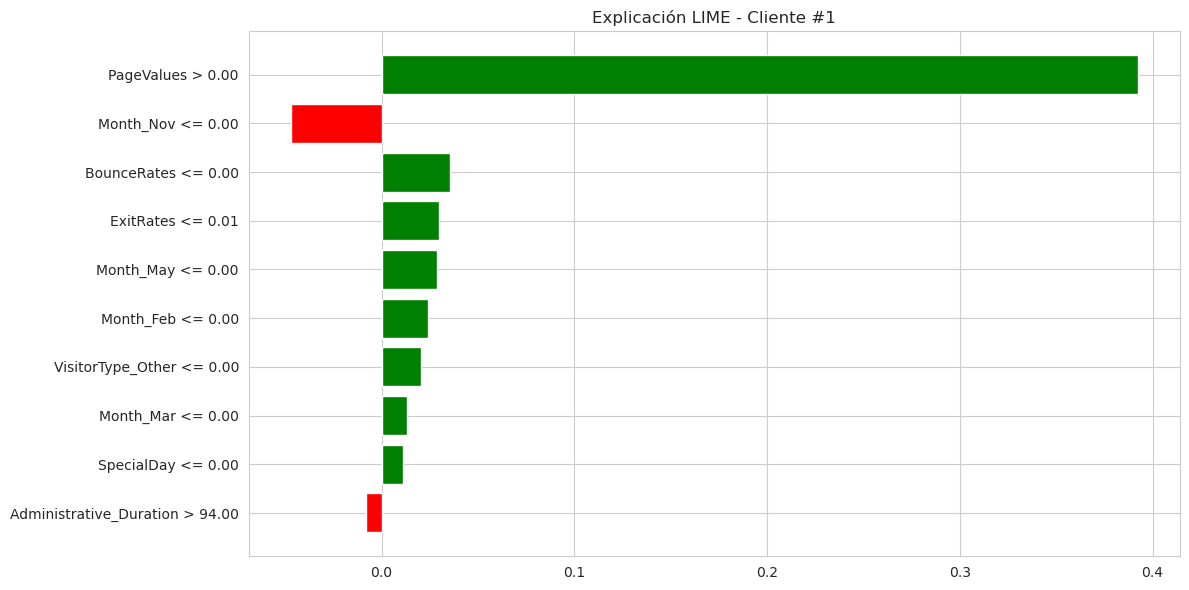


Análisis Cliente #100 con LIME
Realidad: No Compra
Explicación guardada: ../exportaciones/rf-shoppers-lime/explanations/lime_cliente_100.png


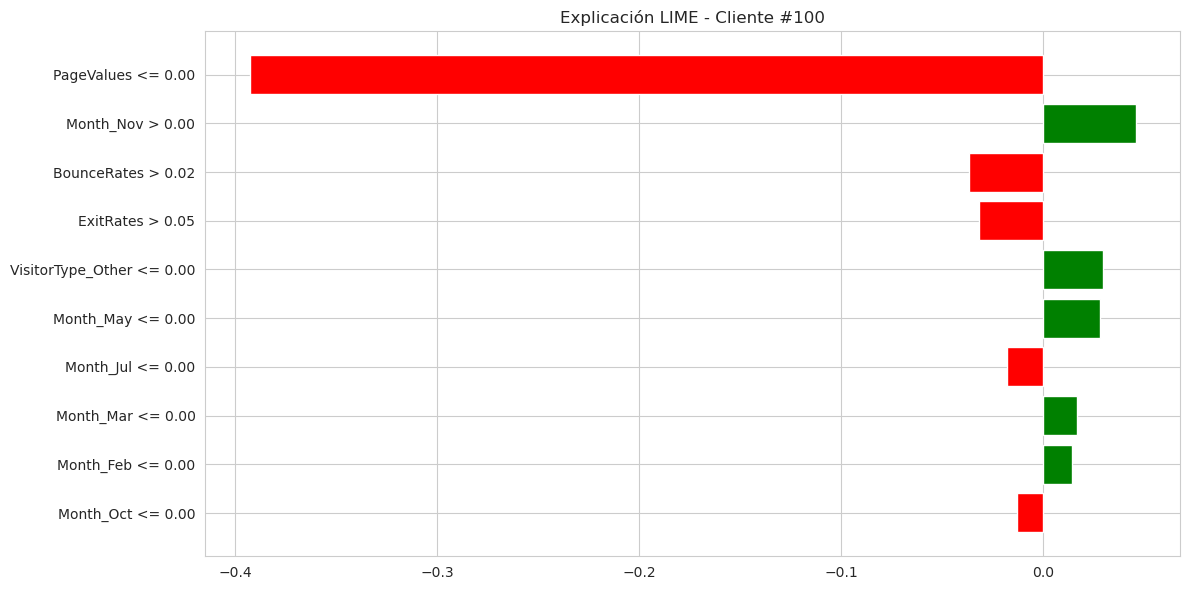


Análisis Cliente #250 con LIME
Realidad: No Compra
Explicación guardada: ../exportaciones/rf-shoppers-lime/explanations/lime_cliente_250.png


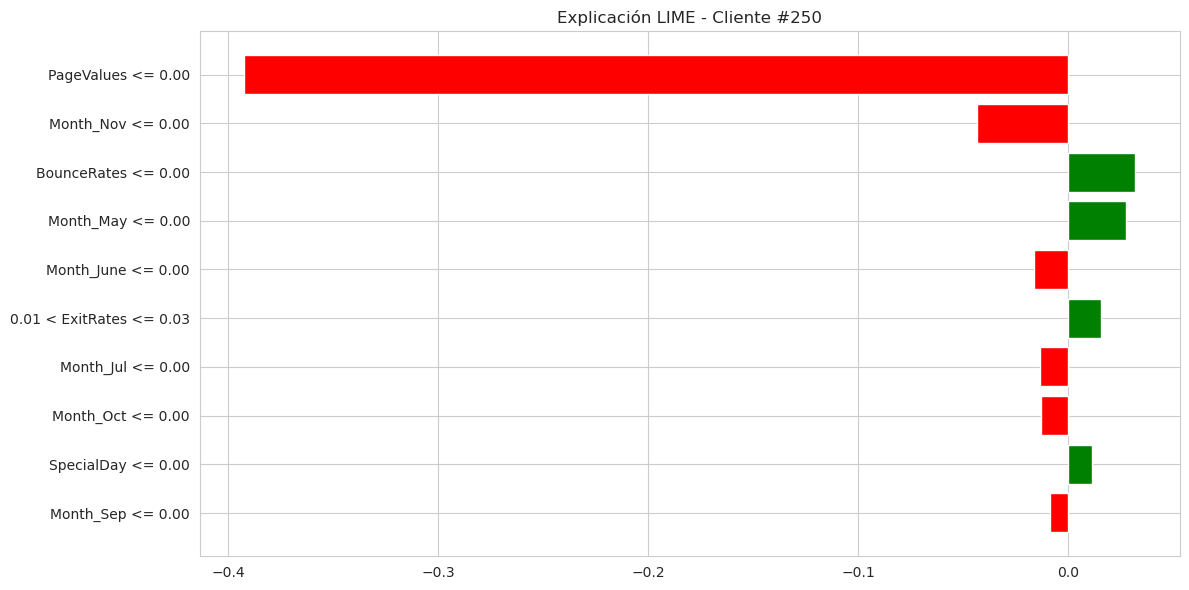


Análisis Cliente #745 con LIME
Realidad: Compra
Explicación guardada: ../exportaciones/rf-shoppers-lime/explanations/lime_cliente_745.png


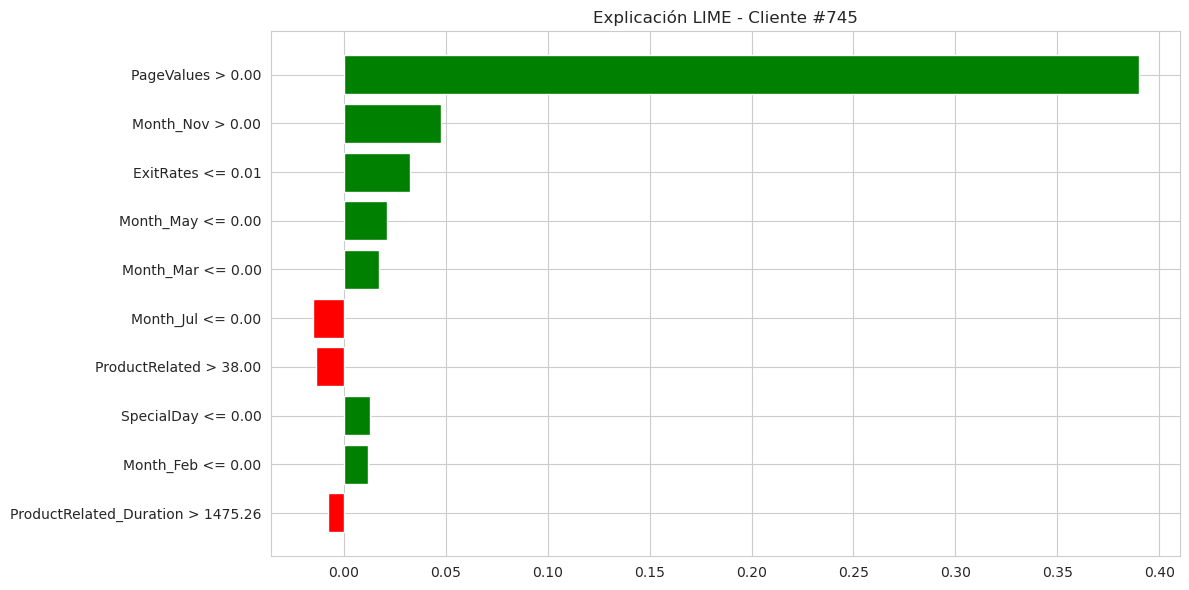

In [39]:
# Función para explicar clientes individuales con LIME y guardar resultados
def explicar_cliente_lime_guardado(idx, model, X_test, y_test, save_path=None):
    # Convertir a numpy si es necesario
    if hasattr(X_test, 'values'):
        X_test_np = X_test.values
    else:
        X_test_np = X_test
        
    cliente_data = X_test.iloc[idx].values if hasattr(X_test, 'iloc') else X_test[idx]
    
    print(f"\nAnálisis Cliente #{idx} con LIME")
    
    # Obtener etiqueta real
    realidad = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    print(f"Realidad: {'Compra' if realidad==1 else 'No Compra'}")
    
    # Crear función wrapper que mantenga los nombres de las características
    def predict_fn_wrapper(data):
        # Convertir numpy array a DataFrame con nombres de columnas
        if isinstance(data, np.ndarray):
            data = pd.DataFrame(data, columns=X.columns)
        return model.predict_proba(data)
    
    # Generar explicación usando el wrapper
    exp = explainer_lime.explain_instance(
        data_row=cliente_data, 
        predict_fn=predict_fn_wrapper,
        num_features=10
    )
    
    fig = exp.as_pyplot_figure()
    plt.title(f"Explicación LIME - Cliente #{idx}")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Explicación guardada: {save_path}")
        # Loggear en MLflow
        mlflow.log_artifact(save_path, "explanations")
    
    plt.show()

# Explicar varios clientes representativos
clientes_ejemplo = [1, 100, 250, 745]
for cliente_idx in clientes_ejemplo:
    exp_path = os.path.join(explanations_dir, f'lime_cliente_{cliente_idx}.png')
    explicar_cliente_lime_guardado(cliente_idx, rf_model, X_test, y_test, save_path=exp_path)

##  ¿Por qué se hace estas pruebas por cliente?

Con LIME podemos **auditar decisiones individuales** del modelo. En lugar de solo decir "este cliente va a comprar", ahora sabemos **POR QUÉ** el modelo piensa eso.

**Casos de uso real:**
1. **Marketing personalizado**: Si sabemos que un cliente tiene alta probabilidad por PageValues, enviamos ofertas de productos premium
2. **Prevención de abandono**: Si detectamos que alguien no va a comprar por ExitRate alta, podemos intervenir con descuentos
3. **Auditoría**: Verificar que el modelo no toma decisiones discriminatorias

---

## Análisis de Clientes Probados

###  Clientes que SÍ Compraron

**Cliente #1**
- **Variables positivas que lo llevaron a comprar:**
  - `PageValues alto` → Visitó páginas de productos valiosos
  - `ProductRelated_Duration alto` → Pasó mucho tiempo viendo productos
  - `BounceRate bajo` → No salió rápido del sitio
  
- **Perfil**: Cliente comprometido, navega profundo, ve productos caros
- **Acción de negocio**: Este es tu cliente ideal. Mantén contenido de calidad.

**Cliente #100**
- **Variables positivas:**
  - `PageValues moderado` → Interés genuino
  - `Month = Noviembre` → Temporada de compras (Black Friday)
  - `VisitorType = Returning_Visitor` → Cliente recurrente
  
- **Perfil**: Cliente fiel que aprovecha temporadas especiales
- **Acción de negocio**: Programa de lealtad y promociones estacionales funcionan

---

### Clientes que NO Compraron

**Cliente #250**
- **Variables negativas que lo alejaron de comprar:**
  - `PageValues ≈ 0` → Solo miró, no interactuó con productos
  - `ExitRate > 0.6` → Salió rápido de las páginas
  - `BounceRate alto` → Entró y se fue casi inmediato
  
- **Perfil**: Tráfico de baja calidad. Posiblemente clickbait o mala publicidad
- **Acción de negocio**: Revisar fuentes de tráfico. Tal vez pausar anuncios en ese canal.

**Cliente #745**
- **Variables negativas:**
  - `ProductRelated_Duration ≤ 10 seg` → No le interesó nada
  - `Month = Mayo` → Mes sin actividad promocional
  - `Weekend = Sí` → Visitó el fin de semana (bajo compromiso)
  
- **Perfil**: Visitante casual sin intención real de compra
- **Acción de negocio**: No invertir recursos en retargeting. Enfocarse en otros perfiles.





### Visualización de árboles individuales

Árbol #0 guardado: ../exportaciones/rf-shoppers-lime/trees/tree_0.png


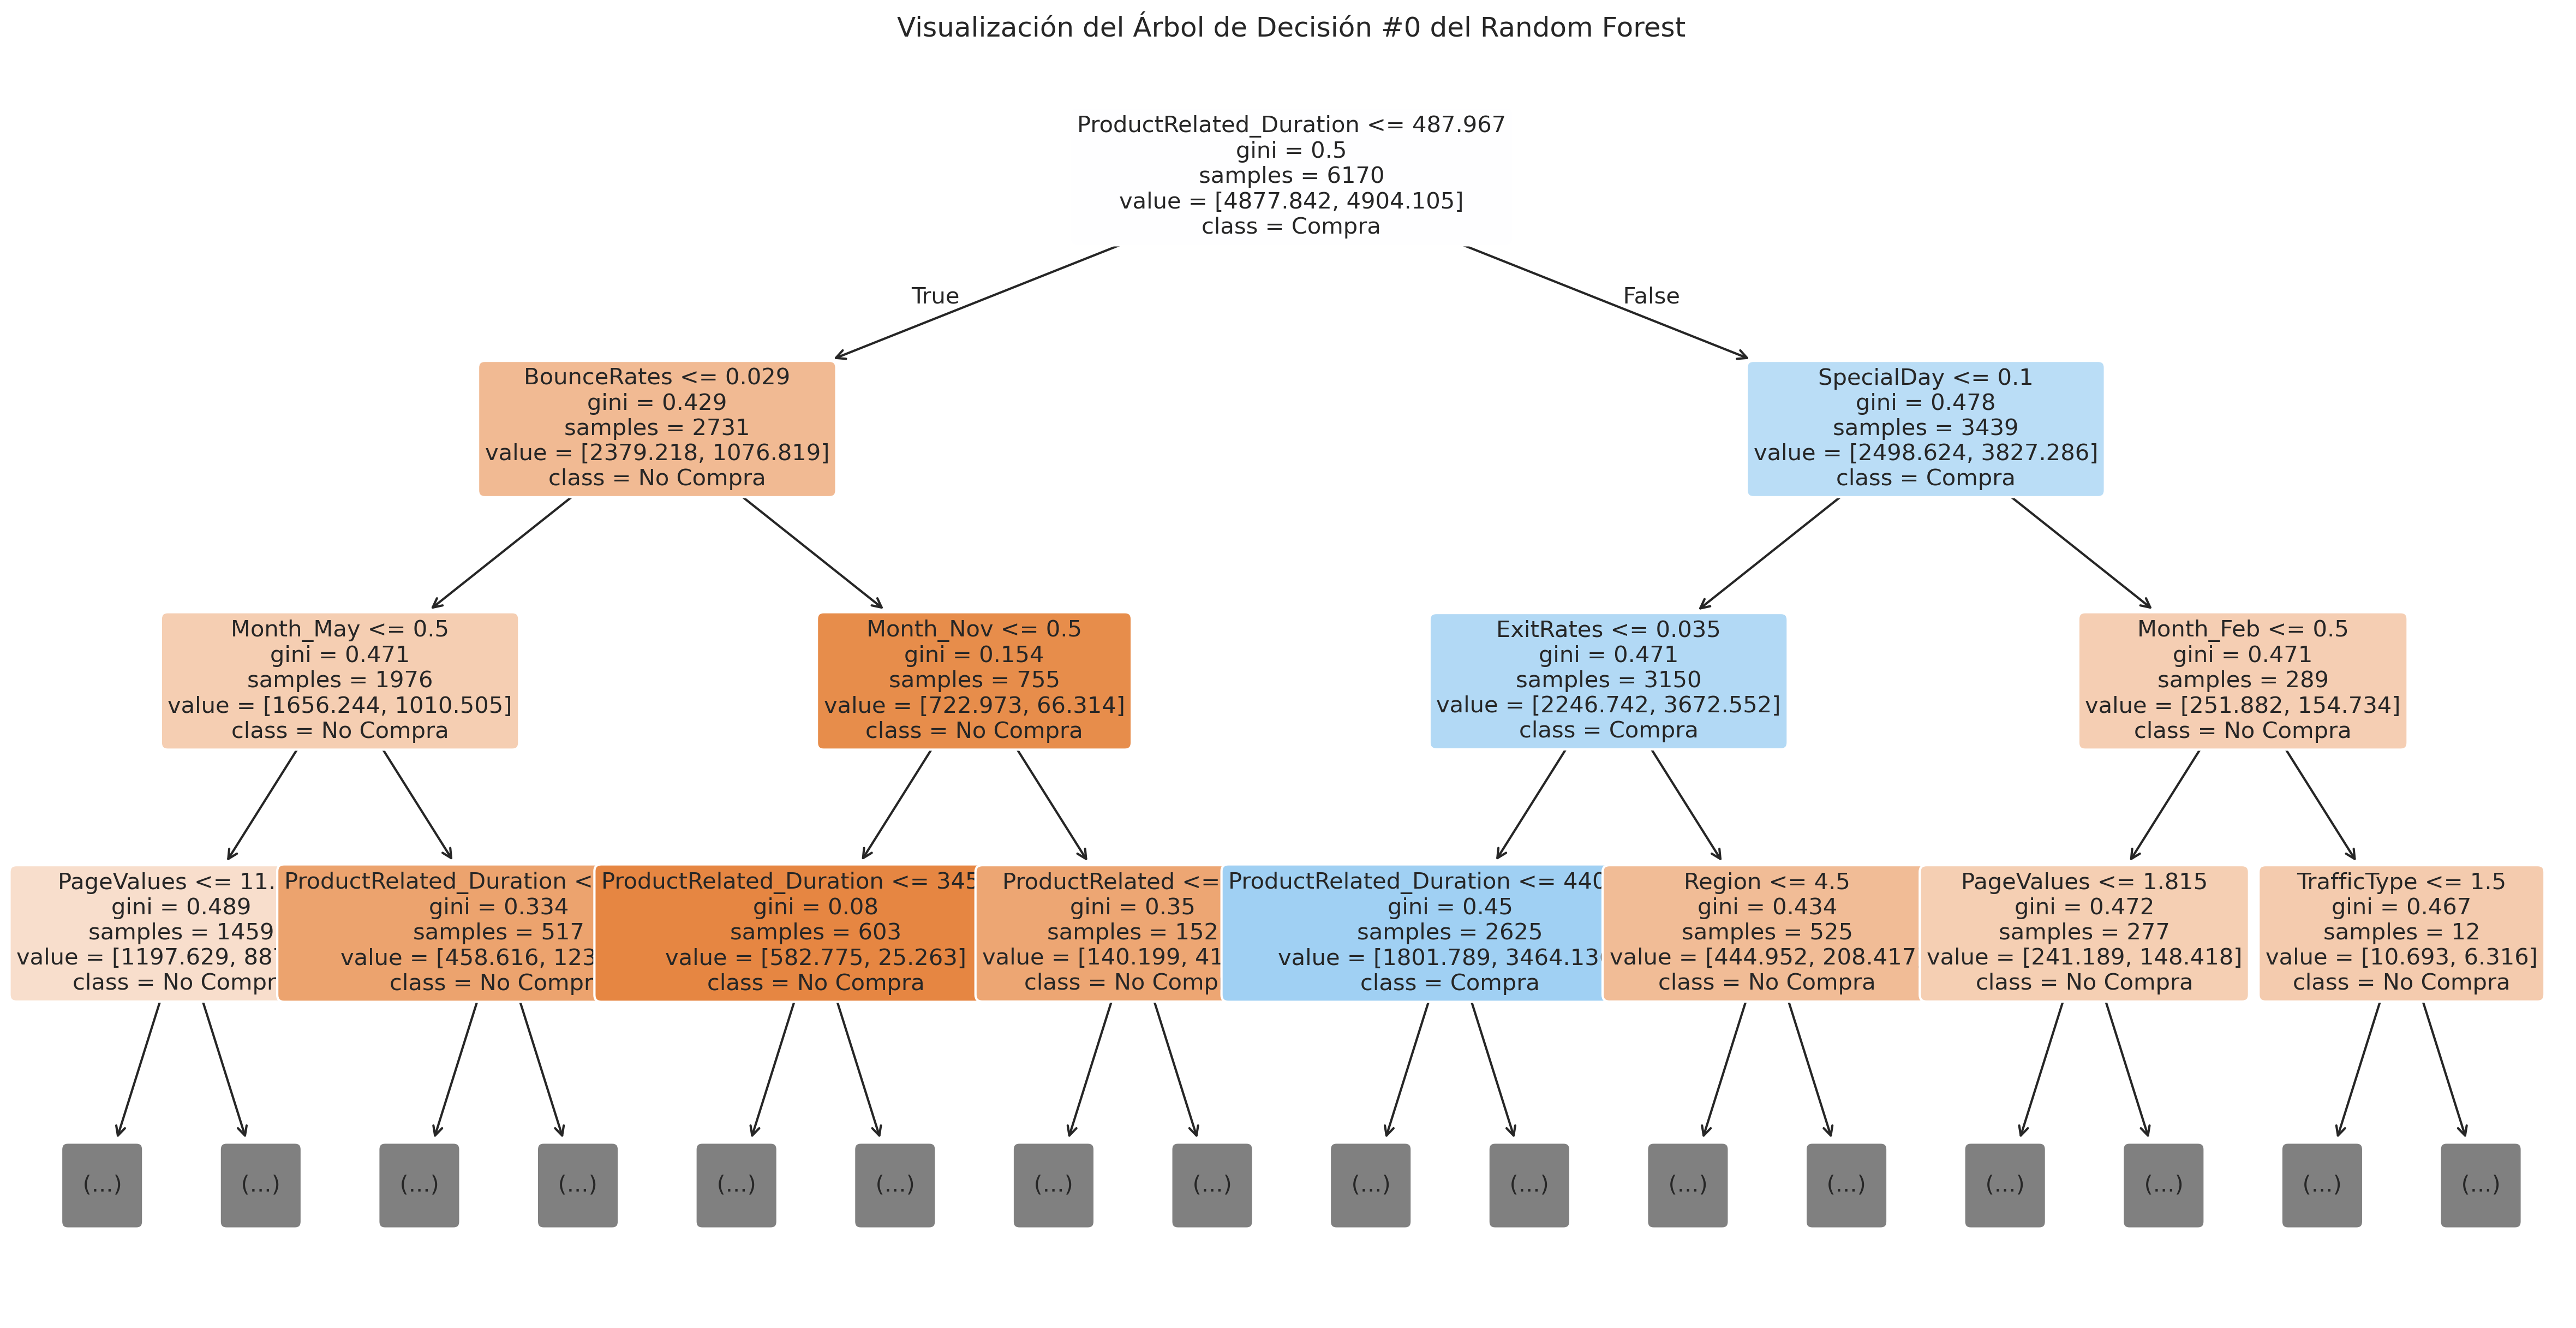

Árbol #1 guardado: ../exportaciones/rf-shoppers-lime/trees/tree_1.png


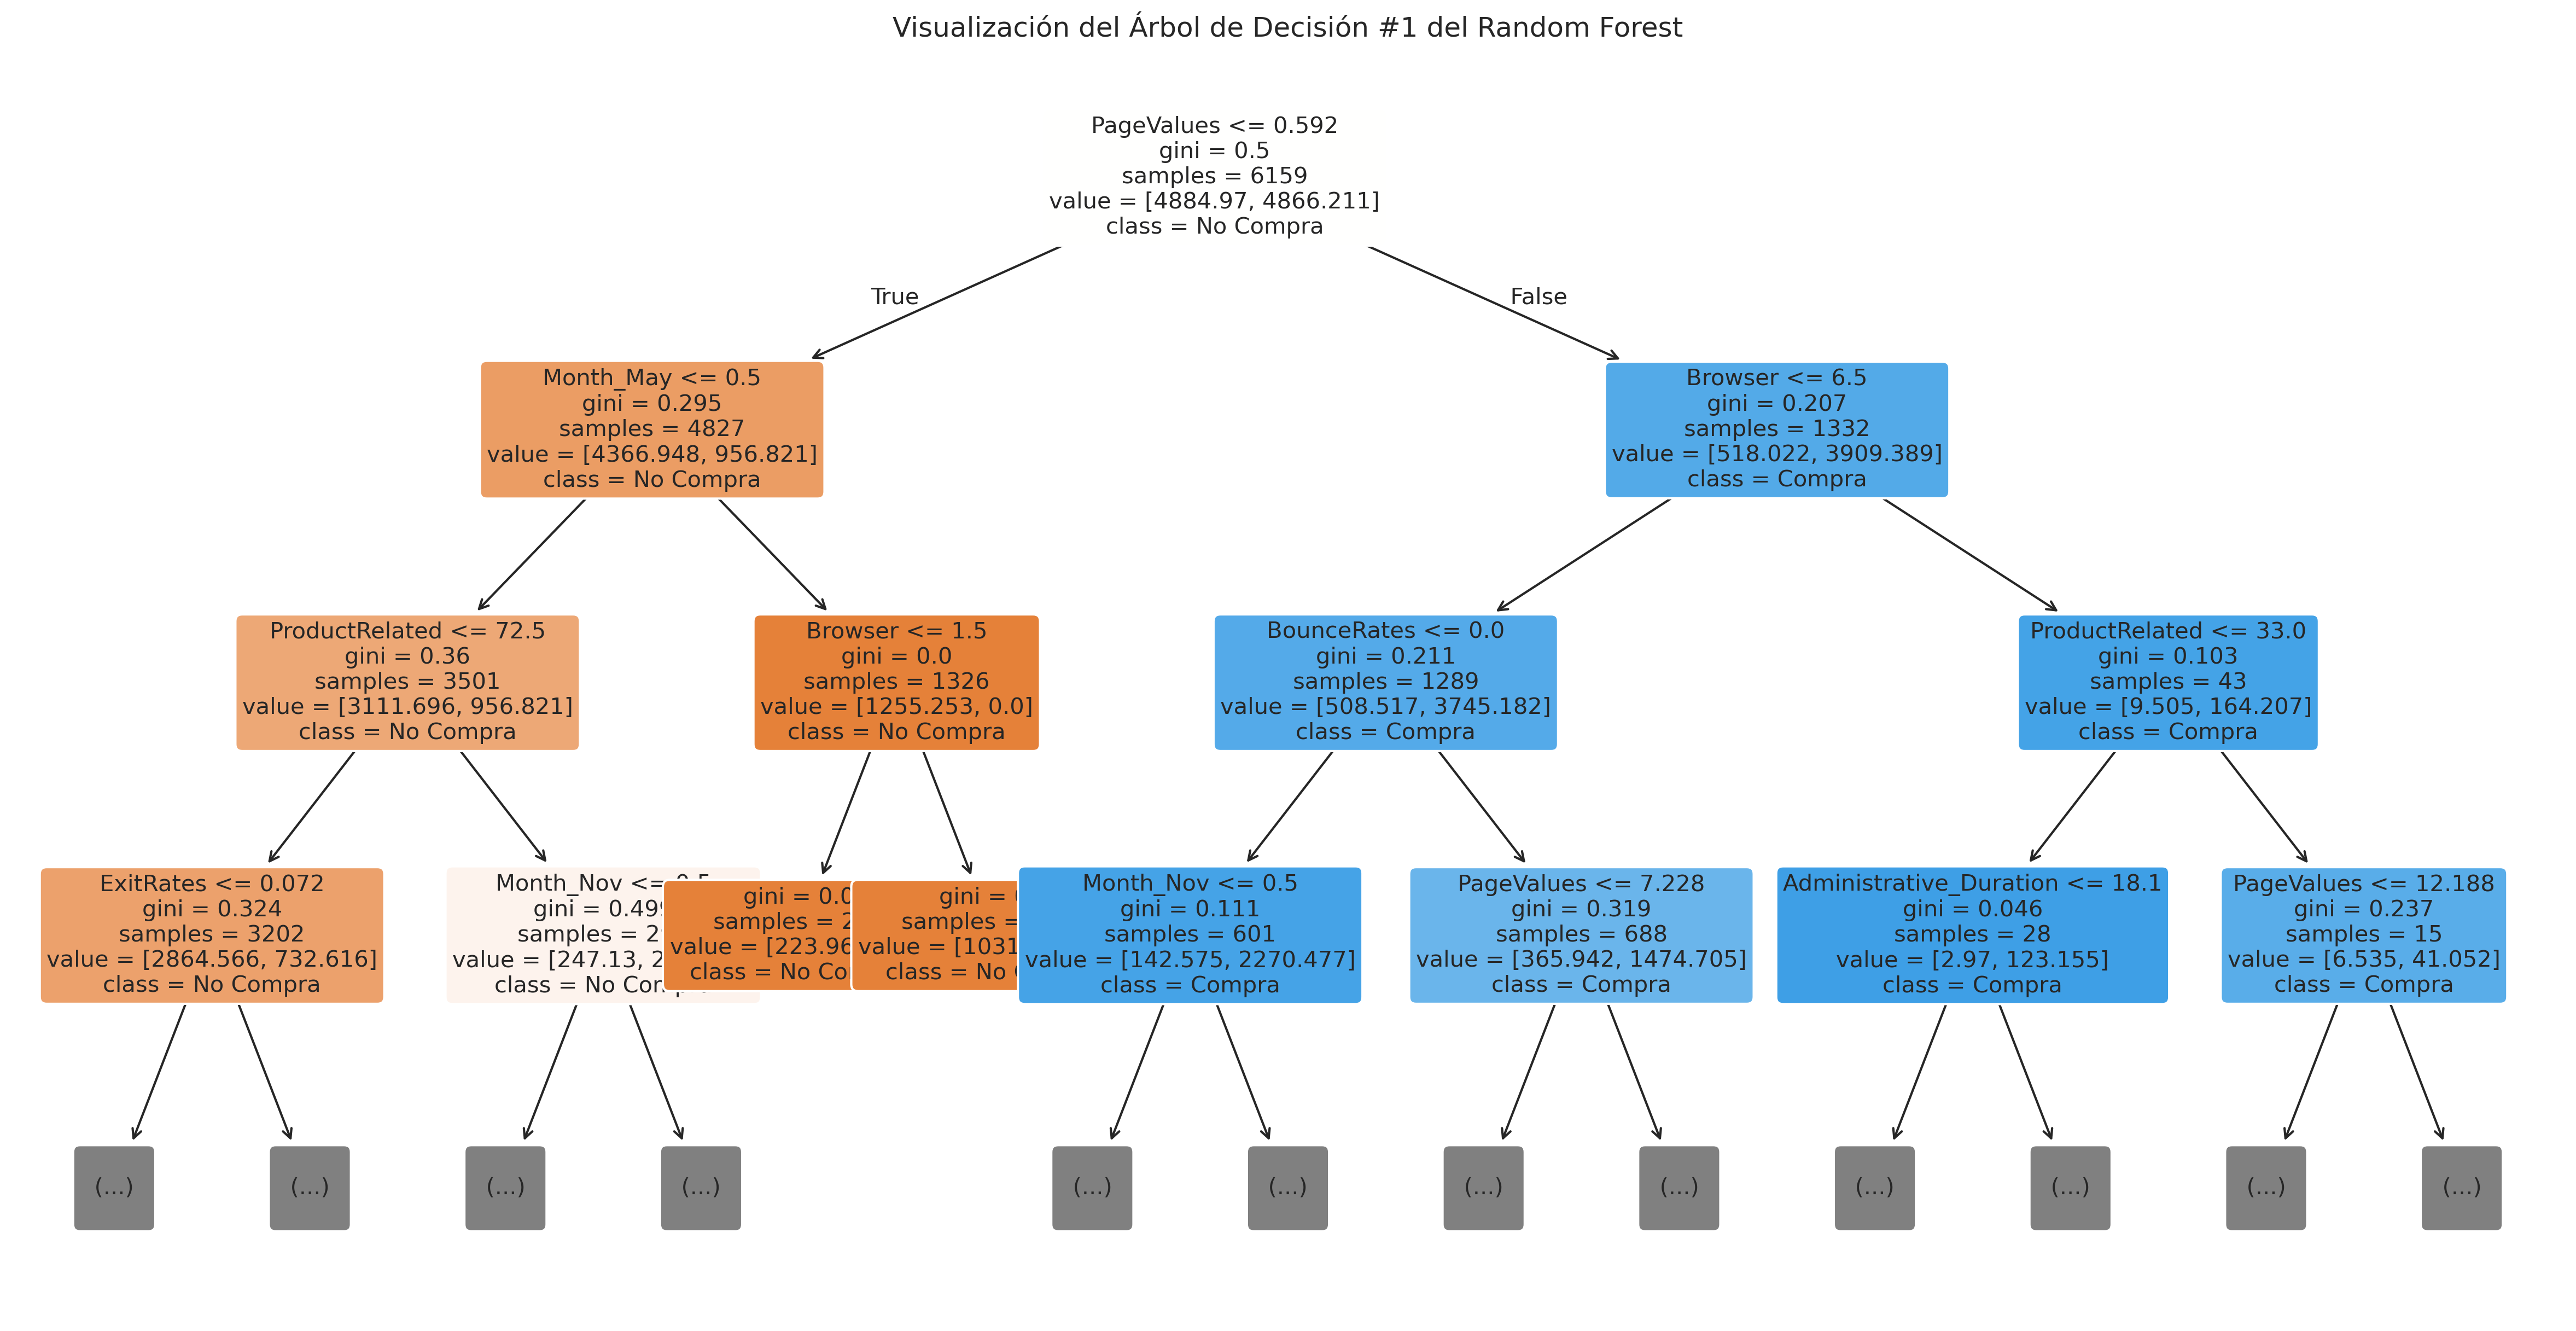

Árbol #2 guardado: ../exportaciones/rf-shoppers-lime/trees/tree_2.png


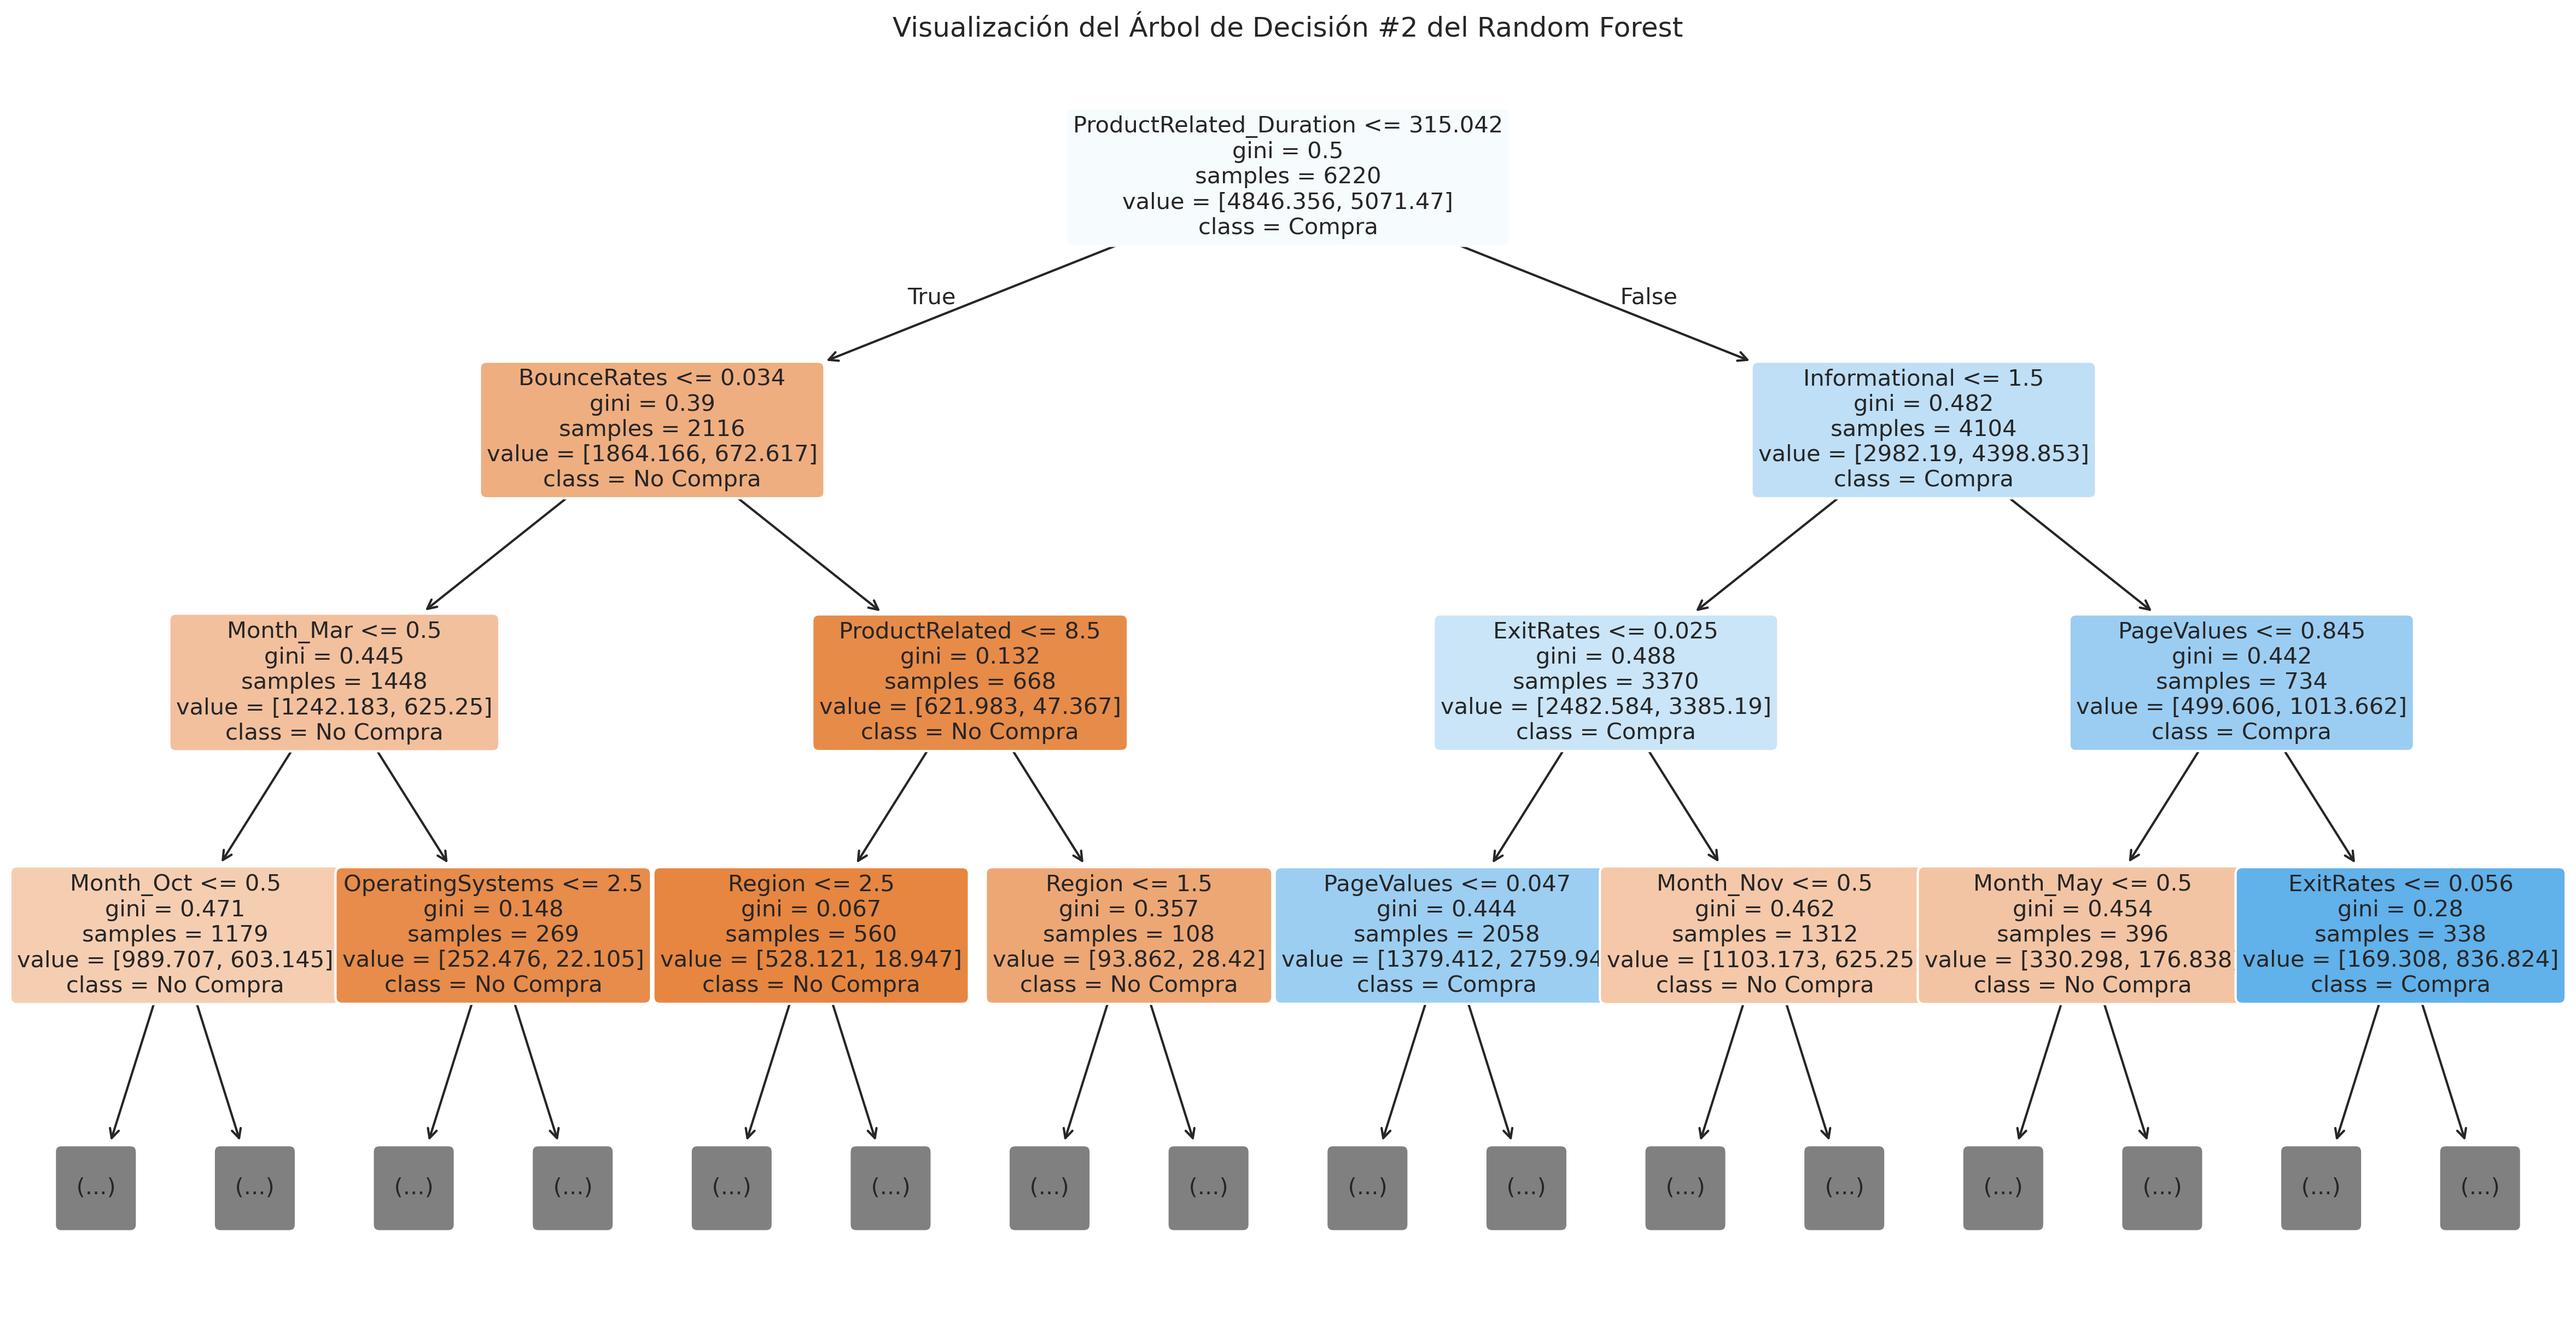

In [26]:
# Función para visualizar árboles individuales con guardado
def graficar_arbol_decision_individual_guardado(rf_model, feature_names, tree_index=0, max_depth=3, save_path=None):
    # Configuración de la figura
    plt.figure(figsize=(20, 10), dpi=300)

    plot_tree(rf_model.estimators_[tree_index], 
            feature_names=feature_names,
            class_names=['No Compra', 'Compra'],
            filled=True,           
            rounded=True,          
            fontsize=10,           
            max_depth=max_depth)

    plt.title(f"Visualización del Árbol de Decisión #{tree_index} del Random Forest")
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Árbol #{tree_index} guardado: {save_path}")
        # Loggear en MLflow
        mlflow.log_artifact(save_path, "trees")
    
    plt.show()

# Visualizar varios árboles representativos
arboles_ejemplo = [0, 1, 2]
for tree_idx in arboles_ejemplo:
    tree_path = os.path.join(trees_dir, f'tree_{tree_idx}.png')
    graficar_arbol_decision_individual_guardado(rf_model, X.columns, tree_index=tree_idx, max_depth=3, save_path=tree_path)

### Exportación del modelo

In [27]:
# Exportar modelo y artefactos
import pickle
import json

# guardar modelo con pickle
model_pickle_path = os.path.join(models_dir, 'random_forest_model.pkl')
with open(model_pickle_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"Modelo guardado: {model_pickle_path}")

# guardar scaler
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler guardado: {scaler_path}")

# guardar nombres de características
features_path = os.path.join(models_dir, 'feature_names.json')
with open(features_path, 'w') as f:
    json.dump(list(X.columns), f, indent=2)
print(f"Nombres de características guardados: {features_path}")

# guardar parámetros del modelo
params_path = os.path.join(models_dir, 'model_params.json')
with open(params_path, 'w') as f:
    json.dump(model_params, f, indent=2)
print(f"Parámetros guardados: {params_path}")

# guardar importancia de características
importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

importances_path = os.path.join(models_dir, 'feature_importances.csv')
importances_df.to_csv(importances_path, index=False)
print(f"Importancias guardadas: {importances_path}")

# loggear todos los artefactos en MLflow
mlflow.log_artifact(model_pickle_path, "model_artifacts")
mlflow.log_artifact(scaler_path, "model_artifacts")
mlflow.log_artifact(features_path, "model_artifacts")
mlflow.log_artifact(params_path, "model_artifacts")
mlflow.log_artifact(importances_path, "model_artifacts")

print("\nTodos los artefactos loggeados en MLflow")

Modelo guardado: ../exportaciones/rf-shoppers-lime/models/random_forest_model.pkl
Scaler guardado: ../exportaciones/rf-shoppers-lime/models/scaler.pkl
Nombres de características guardados: ../exportaciones/rf-shoppers-lime/models/feature_names.json
Parámetros guardados: ../exportaciones/rf-shoppers-lime/models/model_params.json
Importancias guardadas: ../exportaciones/rf-shoppers-lime/models/feature_importances.csv

Todos los artefactos loggeados en MLflow


### Resumen de resultados

In [29]:

print("RESUMEN DE EXPERIMENTO - Random Forest con LIME")
print(f"\nExperimento: {mlflow.get_experiment_by_name('RF-Shoppers-LIME').name}")
print(f"Run ID: {run.info.run_id}")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

print("\n Configuración del modelo ")
print(f"  Algoritmo: Random Forest")
print(f"  Número de árboles: {model_params['n_estimators']}")
print(f"  Balanceo de clases: {model_params['class_weight']}")
print(f"  Técnica XAI: LIME (Local Interpretable Model-agnostic Explanations)")

print("\n Métricas de evaluación ")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")
print(f"  AUC:       {test_auc:.4f}")

print("\n Top 5 características más importantes ")
top_features = importances_df.head(5)
for idx, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


RESUMEN DE EXPERIMENTO - Random Forest con LIME

Experimento: RF-Shoppers-LIME
Run ID: 19fe856afe1045ee96a50100f32a04ae
Tracking URI: file:////home/felipep/Documentos/universidad/universidad 7mo/aprendizaje automatico/practica 3/exportaciones/rf-shoppers-lime/mlruns

 Configuración del modelo 
  Algoritmo: Random Forest
  Número de árboles: 100
  Balanceo de clases: balanced
  Técnica XAI: LIME (Local Interpretable Model-agnostic Explanations)

 Métricas de evaluación 
  Accuracy:  0.9013
  Precision: 0.7469
  Recall:    0.5055
  F1-Score:  0.6030
  AUC:       0.9244

 Top 5 características más importantes 
  PageValues: 0.3900
  ProductRelated_Duration: 0.0923
  ExitRates: 0.0918
  ProductRelated: 0.0677
  BounceRates: 0.0568


## **Resultados**

Al analizar el desempeño del modelo Random Forest, se observa un comportamiento distintivo en comparación con la Red Neuronal previamente entrenada:

* Matriz de Confusión: El modelo demuestra una capacidad de separación clara. Al examinar las hojas del árbol de decisión visualizado, se identifican nodos puros correspondientes a la clase "No Compra" (representados en naranja fuerte) y nodos intermedios con predominancia de la clase "Compra" (azul/celeste), lo que evidencia la lógica de clasificación interna del algoritmo.
* Balanceo de Clases: A pesar de que se implementó el parámetro class_weight='balanced', los nodos del árbol (como aquel con Samples: 2731 y Gini: 0.429 ) evidencian que el modelo aún enfrenta desafíos con la pureza debido a la naturaleza intrínseca de los datos. La presencia de un índice Gini de 0.5 en los nodos superiores indica que, en las etapas iniciales de decisión, el modelo opera bajo una incertidumbre máxima (una mezcla 50/50 de las clases ponderadas), comportamiento esperado en la raíz del árbol antes de aplicar las reglas de segmentación.

## **Explicación de Predicciones con Random Forest**

- Para abrir la "caja negra" del Random Forest, utilizamos tres enfoques complementarios: Importancia Global, LIME (Local) y Análisis Estructural de Árboles.

A. Importancia Global (Impureza de Gini)

- El gráfico de barras horizontales confirma que PageValues es la variable dominante. Sin embargo, el Random Forest revela que variables de comportamiento como ProductRelated_Duration y BounceRates tienen un peso secundario mucho más relevante que en la Red Neuronal, actuando como validadores de la intención de compra.

B. Explicación Local con LIME (Local Interpretable Model-agnostic Explanations)

- Como los árboles no son diferenciables (no tienen gradientes), usamos LIME para explicar clientes individuales. LIME genera un modelo lineal local alrededor de un cliente específico para entender qué movió la aguja.
    - Interpretación del Gráfico LIME:
        Barras Verdes (Soportan la clase "Compra"): Para los clientes analizados, valores altos de PageValues son el motor principal de la decisión positiva.
        Barras Rojas (Soportan la clase "No Compra"): Variables como visitar en Mayo (Month_May) o tener una Tasa de Rebote (BounceRates) alta actúan como penalizadores, restando probabilidad de compra.

C. Visualización y Comparativa de Árboles (La "Democracia" del Modelo)

- Esta es la parte medular del algoritmo. Un Random Forest no es un solo experto, es un comité. Hemos extraído y visualizado dos árboles distintos (Estimadores) del bosque para demostrar su diversidad:
    - Árbol #1 (Enfoque en Calidad de Visita):
        - Nodos Críticos: Este árbol prioriza filtros tempranos de "calidad". Observamos un nodo de decisión BounceRates <= 0.029.
        - Lógica: Si el usuario rebota más del 2.9%, este árbol lo descarta inmediatamente. Es un árbol "estricto" que limpia el tráfico basura rápido.
    - Árbol #2 (Enfoque en Interés/Tiempo):
        - Nodos Críticos: Este estimador toma un camino diferente, enfocándose en la regla ProductRelated_Duration < 487.9.
        - Lógica: Aquí el modelo no mira tanto si el usuario "rebota", sino si "se queda". Establece que se necesitan al menos ~8 minutos (488s) de interacción con productos para considerar la compra probable.

- Conclusión de la Comparativa: Mientras el Árbol #1 actúa como un "filtro de seguridad" (eliminando rebotes), el Árbol #2 actúa como un "detector de interés" (midiendo tiempo). La predicción final del modelo es robusta precisamente porque promedia estas visiones complementarias, algo que un solo Árbol de Decisión no podría hacer.

## **Conclusiones**

- Robustez por Diversidad: La visualización de múltiples árboles demuestra que el éxito del Random Forest radica en la descorrelación. Al obligar a distintos árboles a fijarse en distintas variables (unos en BounceRates, otros en Duration), el modelo final es mucho más estable y menos propenso al sobreajuste que un solo árbol de decisión.

- Reglas de Negocio Accionables: Gracias a la explicabilidad del Random Forest, extrajimos umbrales numéricos exactos para el equipo de marketing:
    - *Insight:* Las campañas que atraigan tráfico con una tasa de rebote superior al 2.9% tienen alta probabilidad de no conversión, según lo indica el tercer nodo de decisión del árbol.
    - *Insight:* Para ser considerado un prospecto viable por el modelo, el usuario requiere interactuar al menos 488 segundos con páginas relacionadas con productos.

Comparativa Final: Mientras que en la Red Neuronal (Parte 1) se usó Gradientes Integrados para ver la "sensibilidad" del modelo, aquí LIME permitió ver los "pesos" de la decisión. Ambos métodos coinciden en que PageValues es la variable rey, pero LIME con Random Forest nos dio una visión más clara de cómo las variables negativas (como meses específicos o tasas de salida) actúan como barreras activas para la compra.